In [1]:
from qiskit import __version__

print(__version__)

2.3.1


# Un qubit

## Básicos operacionales

Suma de arrays y su media

In [2]:
import numpy as np

ket0 = np.array([[1],[0]])
ket1 = np.array([[0],[1]])

print((ket0 + ket1)/2)

[[0.5]
 [0.5]]


Suma de matrices. Mismo principio que antes

In [3]:
M1 = np.array([[1,1], [0,0]])
M2 = np.array([[1,0], [0,1]])

M = (M1 + M2)/2
print(M)

[[1.  0.5]
 [0.  0.5]]


**matmul** es una función de numPy para multiplicación tanto de vectores con matrices, como entre matrices, como entre vectores. 

Para una visualización mucho más limpia, qiskit.visualization tiene funciones específicas que ayudan a la hora de crear estos apuntes específicos. Por lo tanto haciendo uso de **array_to_latex**, se puede obtener un método más limpio de visualización:

In [4]:
from qiskit.visualization import array_to_latex

display(array_to_latex(np.matmul(M1, ket1)))
display(array_to_latex(np.matmul(M1, M2)))
display(array_to_latex(np.matmul(M, M)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Librería Statevector

**NOTA PREVIA**: Así funciona Statevector

- Siempre $ 2^n $ cifras según la cantidad de qubits
- Todo a 0 excepto uno de los índices si es sólo 1 qubit independientemente del statevector
- Cuando hablamos de más de un qubit, implica más 1s en el statevector y se representan sumándose

In [5]:
from qiskit.quantum_info import Statevector
prueba = Statevector([0,1,1,0,1,0, 0,0])
display(prueba.draw("latex"))

<IPython.core.display.Latex object>

Qiskit incluye funciones en sus librerías para definir statevectors de forma directa, de modo que no hay que complicarse la vida realizando una definición desde 0:

In [6]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

Las clases de draw, inlcuídas en la clase Statevector, incluyen formas de mostrar los vectores estado como: texto plano, texto latex o código latex para poder pasárlo a archivos como los de overleaf.

In [7]:
display(u.draw("text"))
display(u.draw("latex"))
print(u.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


*MUCHO MÁS ÚTIL* La clase Statevector permite comprobar de forma instantánea si un vector es un Statevector es válido, es decir, si su norma Euclídea equivale a 1.

In [8]:
display(u.is_valid())
display(w.is_valid())

True

False

## Medidas

Es posible también realizar mediciones gracias a los métodos de la clase Statevector. Para esto se usará el vector v previamente visto.

In [9]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

El método **measure** simula una medición en la base estándar:

In [10]:
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

Los resultados de las mediciones son probabilísitcos, por lo que este código puede devolver distintos valores si se lanza múltiples veces. Los resultados más comunes son *equivalentes respecto a una fase global* porque uno es equivalente a otro multiplicado por cierto número complejo en la circunferencia unidad.

Statevector devuelve un error si se intenta medir un statevector inválido con la función measure.

Para realizar un número arbitrario de mediciones sobre el sistema, la librería cuenta con la función sample_counts. Simula cualquier número de medidas, cada una con una copia nueva del statevector. Puede usarse **plot_histogram** para visualizar la estadística en un histograma:

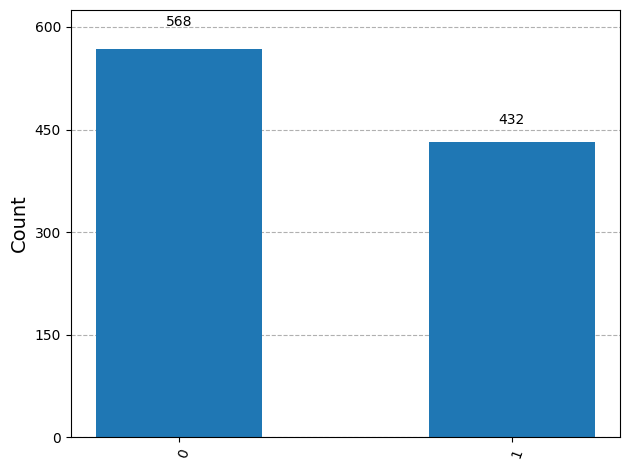

In [11]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

## Operaciones con *Operator* y *Statevector*

Operaciones Unitarias pueden ser definidas desde la clase Operator. La operación "latex" lleva a cabo la misma funcionalidad que "array_to_latex"

In [12]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(Y.draw("latex"))
display(H.draw("latex"))
display(S.draw("latex"))
display(T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Mediante el método **evolve** se puede aplicar una operación unitaria a un statevector. Es una forma de mantener el estado original. Un objeto de la clase **Operator** no puede aplicar estas operaciones; sin emargo, si puede un objeto de la clase **Statevector**. Por lo tanto, aplicar evolve se podría considerar aplicar una operación unitaria a la izquierda del statevector o de la matriz en general sobre la que se quiere trabajar, manteniendo el tipo para aplicar futuros *evolves* en lugar de transformarlo accidentalmente en un tensor sobre el que solo se pueden aplicar productos tensoriales.

In [13]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

Los circuitos cuánticos se introducen más adelante. Mientras tanto, haciendo uso de la clase **QuantumCircuit** es posible realizar operaciones unitarias compuestas, las cuales teóricamente reflejan un circuito cuántico.

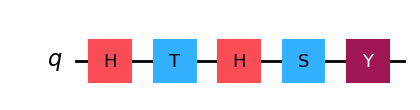

In [14]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

Las operaciones se aplican de izquierda a derecha, y se puede ver el operador que dan como resultado mediante **Operator**

In [15]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

Como se observó previamente, ahora se realizará de nuevo: Se inicializará un statevector y se le aplicarán todas las operaciones del circuito. Luego, se mide mediante una base estándar múltiples veces como se vio previamente mediante **sample_counts**

In [16]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

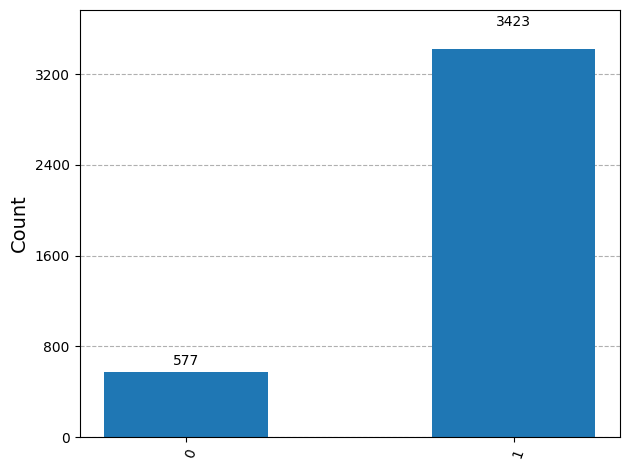

In [17]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))

# Múltiples Qubits

## Productos tensoriales

La clase Statevector tiene un método tensor, el cual devuelve, como su propio nombre indica, el producto tensorial. El ejemplo a continuación toma las etiquetas 0 y 1 y las convierte en sus correspondientes statevectors, luego realiza el producto tensorial y su representación con el método de display ya visto:

**NOTA**: También es posible obtener el producto tensorial haciendo uso del símbolo ^

In [18]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
psi = zero.tensor(one)
display(psi.draw("latex"))

<IPython.core.display.Latex object>

Hay más etiquetas permitidas como por ejemplo **+** y **-** para los correspondientes estados, y **r** y **l** para right y left. Todas estas etiquetas provienen del contexto del spin de los qubits. Se visualiza a continuación todos los statevectors mencionados junto al tensor de **+** y **l**:

In [19]:
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")
minus = Statevector.from_label("-")
plus_i = Statevector.from_label("r")

display(plus.draw("latex"))
display(minus.draw("latex"))
display(plus_i.draw("latex"))
display(minus_i.draw("latex"))

phi = plus.tensor(minus_i)
display(phi.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

La clase **Operator** también cuenta con un método tensor: (también funciona el símbolo ^ igual que antes)

In [20]:
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")
display(H.tensor(Id).draw("latex"))
display(H.tensor(Id).tensor(X).draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Es posible aplicar operaciones unitarias a sistemas compuestos, u operaciones compuestas a estados compuestos. Por ejemplo, realizar el producto tensorial de una Hadamard **H** y una identidad **I** ($H \otimes I $) para el statevector $\lvert \phi \rangle = \lvert + \rangle \otimes \lvert -i \rangle $

In [21]:
display(phi.evolve(H ^ Id).draw("latex"))

<IPython.core.display.Latex object>

A continuación, el ejemplo de la aplicación de las operaciones $ CX $. Estas calculan  $ CX \lvert \psi \rangle = \lvert + \rangle \otimes \lvert 0 \rangle $. En estas el qubit izquierdo es el control y el derecho el "target". El resultado es el estado de Bell $ \lvert \phi^+ \rangle $

In [22]:
CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
psi = plus.tensor(zero)
display(psi.evolve(CX).draw("latex"))

<IPython.core.display.Latex object>

## Medidas parciales

Por defecto el método **measure** computa las medidas de todos los qubits en el statevector. Alternativamente, se le puede pasar una lista de *integers*. Con esta solamente se medirían aquellos índices de qubit que correspondan a la lista. Por supuesto si no existe el índice, habrá un error. Como ejemplo, el código a continuación crea el estado:

# $ \lvert w \rangle = \frac{\lvert 001 \rangle + \lvert 010 \rangle + \lvert 100 \rangle}{\sqrt{3}}$

Y lo mide en el qubit 0. 
**NOTA**: El qubit 0 es el que está más a la derecha. Esto es una cuestión de notación con la que hay que tener mucho cuidado y que se recalcará más adelante. 

In [23]:
w = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / sqrt(3))
display(w.draw("latex"))

result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

result, state = w.measure([0, 1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

<IPython.core.display.Latex object>

Measured: 0
State after measurement:


<IPython.core.display.Latex object>

Measured: 00
State after measurement:


<IPython.core.display.Latex object>

# Entrelazamiento en acción

In [24]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

### Previo: Estados de Bell

Los estados de Bell son extremadamente importantes para todo lo relacionado con teleportación cuántica o incluso el protocolo CHSH dado a que son estados entrelazados muy reconocibles. Por lo tanto es de consideración importante conocer estos estados y a la vez ser capaz de obtenerlos mediante circuitos cuánticos, comprobando como se obtienen. Cabe recordar que un circuito cuántico parte de que por defecto entra un qubit en $\lvert 0 \rangle$. Por lo tanto a continuación y como prueba personal, se conseguirán todos los estados de Bell y se explicará como se llega a estos.

Cabe recordar que dado que los estados de Bell son estados entrelazados; hacen falta dos qubits que entrelazar. Por lo tanto nuestro circuito cuántico contará con dos estados A y B. Una Hadamard proporcionará la superposición de estados lo cual automáticamente da lugar a:

- $H \space \lvert 0 \rangle = \lvert + \rangle$
- $H \space \lvert 1 \rangle = \lvert - \rangle$

A partir de ese punto solo es necesario establecer el entrelazamiento mediante una puerta que lo permita como sería el caso de una $CNOT$. Por otro lado el qubit con el que se quiere entrelazar cambiaría apropiadamente según el estado que se desee formar.

Primero un método de visualización resumido que se llamará siempre que se quiera ver el statevector que devuelve un circuito.

In [25]:
def visualization(qc):
    statevector = Statevector.from_instruction(qc)
    display(statevector.draw("latex"))

El primer estado de Bell es el:

$$
\lvert \phi^+ \rangle = \frac{1}{\sqrt{2}}(\lvert 00 \rangle + \lvert 11 \rangle)
$$

Esto significa que una $CNOT$ básica ya crearía el estado que se desea. Se puede probar de forma matemática aplicando la Hadamard al qubit A y la identidad al qubit B. Luego realizando la $CNOT$ entre ellos podemos obtener el resultado final tal que:

In [26]:
def math_phi_plus():
    H = Operator.from_label("H")
    Id = Operator.from_label("I")
    a = Statevector([1,0,0,0])
    CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
    
    operator = H.tensor(Id)
    
    phi = a.evolve(operator)
    display(phi.evolve(CX).draw("latex"))

    
math_phi_plus()

<IPython.core.display.Latex object>

En la versión circuito:

- Se parte de dos qubits.
- Mediante una Hadamard en el primer qubit, este se convierte en una superposición de 0 y 1, el segundo qubit queda como estaban antes los originales. La forma más clara de verlo es que si los qubits son $\lvert BA \rangle \space$ mediante la Hadamard quedan tal que $\lvert B_0 A_0 \rangle + \lvert B_1 A_1 \rangle$.
- Dado que hay una puerta de control, quedan entrelazados los dos qubits.
- Por la superposición causada por la Hadamard, uno de los controles se activa y provoca que el $\lvert 11 \rangle \space$ de la derecha.

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

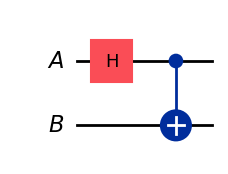

<IPython.core.display.Latex object>

In [27]:
def circuit_phi_plus():
    zero = QuantumRegister(1,"A")
    one = QuantumRegister(1,"B")
    qc = QuantumCircuit(zero,one)
    
    visualization(qc)
    qc.h(zero)
    visualization(qc)
    qc.cx(zero,one)
    
    display(qc.draw(output="mpl"))
    visualization(qc)
    
    

circuit_phi_plus()

El segundo estado de Bell es el:
$$
\lvert \phi^- \rangle = \frac{1}{\sqrt{2}}(\lvert 00 \rangle - \lvert 11 \rangle)
$$
El único cambio es el signo en el segundo par, lo cual debería ser bastante intuitivo. La forma más simple es empleando una puerta inversa en el circuito y un qubit 1 en la forma matemática:

In [28]:
def math_phi_minus():
    H = Operator.from_label("H")
    Id = Operator.from_label("I")
    a = Statevector([0,0,1,0])
    CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
    
    operator = H.tensor(Id)
    
    phi = a.evolve(operator)
    
    display(phi.evolve(CX).draw("latex"))

    
math_phi_minus()

<IPython.core.display.Latex object>

### *NOTA IMPORTANTÍSIMA*:
Cuando hablamos de **CIRCUITOS** el qubit más a la derecha es el primer qubit del circuito. Cuando hablamos de **STATEVECTORS** es al revés, el qubit más a la izquierda sería el primero. Es decir, una CNOT aplicada en un statevector de 2 qubits depende del que está más a la izquierda, en un circuito depende del que está más a la derecha que a su vez sería el que está en la primera línea.

En la versión circuito:

- Se parte de dos qubits.
- Mediante una Hadamard en el primer qubit, este se convierte en una superposición de 0 y 1. Como se parte de un qubit 1, el estado quedaría en negativo por salir de $\lvert - \rangle$. El segundo qubit queda como estaban antes los originales. La forma más clara de verlo es que si los qubits son $\lvert BA \rangle \space$ mediante la Hadamard quedan tal que $\lvert B_0 A_0 \rangle + \lvert B_1 A_1 \rangle$.
- Dado que hay una puerta de control, quedan entrelazados los dos qubits.
- Por la superposición causada por la Hadamard, uno de los controles se activa y provoca que el $\lvert 11 \rangle \space$ de la derecha.

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

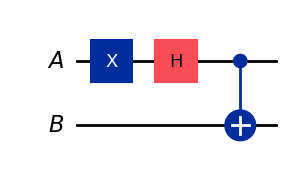

<IPython.core.display.Latex object>

In [29]:
def circuit_phi_minus():
    zero = QuantumRegister(1,"A")
    one = QuantumRegister(1,"B")
    qc = QuantumCircuit(zero,one)
    
    visualization(qc)
    qc.x(zero)
    visualization(qc)
    qc.h(zero)
    visualization(qc)
    qc.cx(zero,one)
    
    display(qc.draw(output="mpl"))
    visualization(qc)
    
    

circuit_phi_minus()

El tercer estado de Bell es el:

$$
\lvert \psi^+ \rangle = \frac{1}{\sqrt{2}}(\lvert 01 \rangle + \lvert 10 \rangle)
$$

La implicación aquí por supuesto es que la $CNOT$ está siendo activada por el qubit y cambiando el estado, manteniendo el positivo en el signo que suma la división creada por la Hadamard. Por lo tanto, la forma matemática y circuito son:

In [30]:
def math_psi_plus():
    H = Operator.from_label("H")
    Id = Operator.from_label("I")
    a = Statevector([0,1,0,0])
    CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
    
    operator = H.tensor(Id)
    
    psi = a.evolve(operator)
    
    display(psi.evolve(CX).draw("latex"))

    
math_psi_plus()

<IPython.core.display.Latex object>

Por lo tanto comparado al método matemático lo que se ve aquí es: 

- Se parte de dos qubits.
- Mediante una Hadamard en el primer qubit, este se convierte en una superposición de 0 y 1, el segundo qubit queda como estaban antes los originales. La forma más clara de verlo es que si los qubits son $\lvert BA \rangle \space$ mediante la Hadamard quedan tal que $\lvert B_0 A_0 \rangle + \lvert B_1 A_1 \rangle$.
- Dado que hay una puerta de control, quedan entrelazados los dos qubits.
- Por la superposición causada por la Hadamard, uno de los controles se activa y provoca que el $\lvert 11 \rangle \space$ de la derecha.
- El qubit B se le aplica una $CX$ cambiando sus qubits asociados por el contrario.

El resultado final queda de la siguiente forma:
- $B_0$:
    - Pasa a 1 debido a que se cambia a negativo con la puerta en el paso CX.
    - Al activarse $A_0$ vuelve a 0 y este es su resultado final.
- $A_0$:
    - División 0 del Hadamard sobre A en el paso H.
    - Se ve afectada retroactivamente debido al CX al entrelazar los qubits mediante la CNOT.
    - Cambia el estado de $B_0$
- $B_1$:
    - Pasa a 1 debido a que se cambia a negativo con la puerta en el paso CX.
- $A_1$:
    - División 1 del Hadamard sobre A en el paso H.
    - Se ve afectada retroactivamente debido al CX al entrelazar los qubits mediante la CNOT, pasando a 0.
    - Como ya no es un 1, no se activa y por lo tanto no cambia el valor de $B_1$.

Initialization


<IPython.core.display.Latex object>

After Hadamard on A


<IPython.core.display.Latex object>

After CX on qubit B


<IPython.core.display.Latex object>

After CNOT


<IPython.core.display.Latex object>

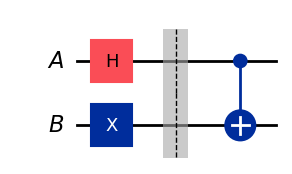

<IPython.core.display.Latex object>

In [31]:
def circuit_psi_plus():
    zero = QuantumRegister(1,"A")
    one = QuantumRegister(1,"B")
    qc = QuantumCircuit(zero,one)
    
    print("Initialization")
    visualization(qc)
    
    print("After Hadamard on A")
    qc.h(zero)
    visualization(qc)
    
    print("After CX on qubit B")
    qc.x(one)
    qc.barrier()
    visualization(qc)
    
    print("After CNOT")
    qc.cx(zero,one)
    visualization(qc)
    
    display(qc.draw(output="mpl"))
    visualization(qc)
    
    

circuit_psi_plus()

Finalmente, el cuarto estado de Bell es el:

$$
\lvert \psi^- \rangle = \frac{1}{\sqrt{2}}(\lvert 01 \rangle - \lvert 10 \rangle)
$$

Toda la explicación principal se mostró en el tercer estado de Bell. Para el cuarto es una simple cuestión de cambio de signo que se mostró previamente en el $\lvert \psi^- \rangle \space$. En cuestión matemática es un cambio de statevector, y en el circuito una $CX$ antes de la Hadamard tal que así:

In [32]:
def math_psi_minus():
    H = Operator.from_label("H")
    Id = Operator.from_label("I")
    a = Statevector([0,0,0,1])
    CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
    
    operator = H.tensor(Id)
    
    psi = a.evolve(operator)
    
    display(psi.evolve(CX).draw("latex"))

    
math_psi_minus()

<IPython.core.display.Latex object>

Initialization


<IPython.core.display.Latex object>

First CX on qubit A to later obtain ket |->


<IPython.core.display.Latex object>

After CX on qubit B


...

<IPython.core.display.Latex object>

Undoing the CX on qubit A before the entaglement so when the retroactivity happens it will change the overallsymbols of the statevector


<IPython.core.display.Latex object>

After CNOT


<IPython.core.display.Latex object>

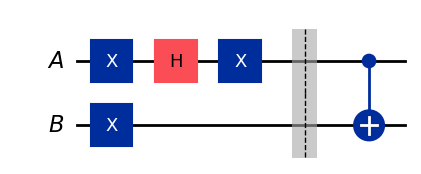

<IPython.core.display.Latex object>

In [33]:
def circuit_psi_minus():
    zero = QuantumRegister(1,"A")
    one = QuantumRegister(1,"B")
    qc = QuantumCircuit(zero,one)
    
    print("Initialization")
    visualization(qc)
    
    print("First CX on qubit A to later obtain ket |->")
    qc.x(zero)
    visualization(qc)
    
    print("After CX on qubit B")
    qc.x(one)
    visualization(qc)
    
    print("After Hadamard on A")
    qc.h(zero)
    visualization(qc)
    
    print("Undoing the CX on qubit A before the entaglement so when the retroactivity happens it will change the overall"
          "symbols of the statevector")
    qc.x(zero)
    visualization(qc)
    qc.barrier()
       
    print("After CNOT")
    qc.cx(zero,one)
    visualization(qc)
    
    
    display(qc.draw(output="mpl"))
    visualization(qc)
    
    

circuit_psi_minus()

## Protocolo de teleportación

Para recrear el protocolo de teleportación entre Alice (A) y Bob (B), es necesario crear un circuito que posea las siguientes características: un qubit Q, ebit de Alice A, ebit de Bob B. Una vez establecidos los preliminares, se puede realizar una operación cualquiera sobre el ebit de Alice. Luego se aplica el protocolo tal cual en la teoría:

Todo se verá más claro en el circuito a continuación:

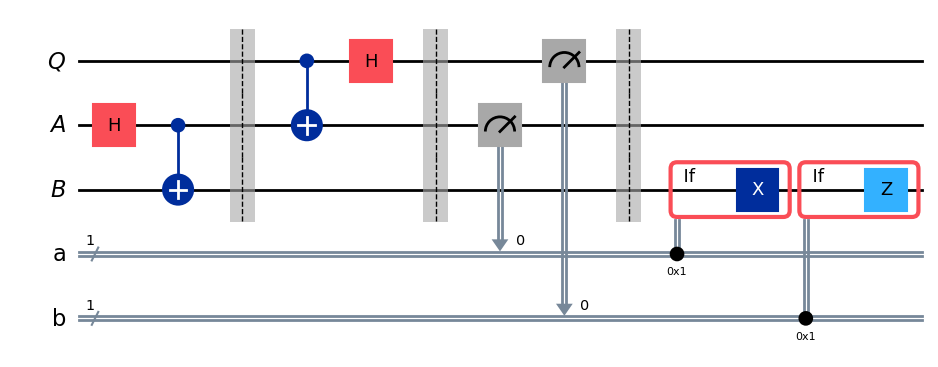

In [35]:
#Definiciones de los registros cuánticos del qubit Q y los ebits A y B respectivament, así como los registros clásicos donde
#se almacemarán los cambios correspondientes.
qubit = QuantumRegister(1, "Q")
ebitA = QuantumRegister(1, "A")
ebitB = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

#Creación del circuito cuántico "protocolo", basado en los registros previamente definidos. 3 cuánticos 2 clásicos
protocol = QuantumCircuit(qubit, ebitA, ebitB, a, b)

#Preparación de teleportación cuántica tal cual vista en la teoría (estado de Bell)
protocol.h(ebitA)
protocol.cx(ebitA, ebitB)
protocol.barrier()

#Segunda fase del protocolo, CNOT y Hadamard conectadas al qubit Q. (Operaciones de Alice)
protocol.cx(qubit,ebitA)
protocol.h(qubit)
protocol.barrier()

#Tercera fase del protocolo, Alice realiza las medidas y envía los bits clásicos a Bob.
protocol.measure(ebitA, a)
protocol.measure(qubit, b)
protocol.barrier()

#Última fase del protocolo. Bob emplea los bits recibidos para aplicar rotaciones de forma condicional.
with protocol.if_test((a,1)):
    protocol.x(ebitB)
with protocol.if_test((b,1)):
    protocol.z(ebitB)
    
display(protocol.draw(output="mpl"))

Un par de cosas novedosas en estos circuitos son las *barriers* que permiten mejor lectura y previenen que qiskit realice ciertas optimizaciones y simplificaciones por detrás cuando se lanza en entornos reales. La función **if_test** es esencialmente una sentencia if en un circuito, solo permitiendo que se ejecute la acción según si se cumple la condición.

Para garantizar la correcta funcionalidad del protocolo, se puede añadir una puerta randomizada que se aplica a la inicialización en $\lvert 0 \rangle $, para obtener un estado aleatorio antes de la teleportación, y aplicar la inversa (o **conjugada traspuesta, adjunta**) de esta puerta al ebit de Bob tras el protocolo. Si vuelve al qubit $\lvert 0 \rangle \space$ el protocolo fue exitoso. 

In [36]:
#Puerta unitaria randomizada
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

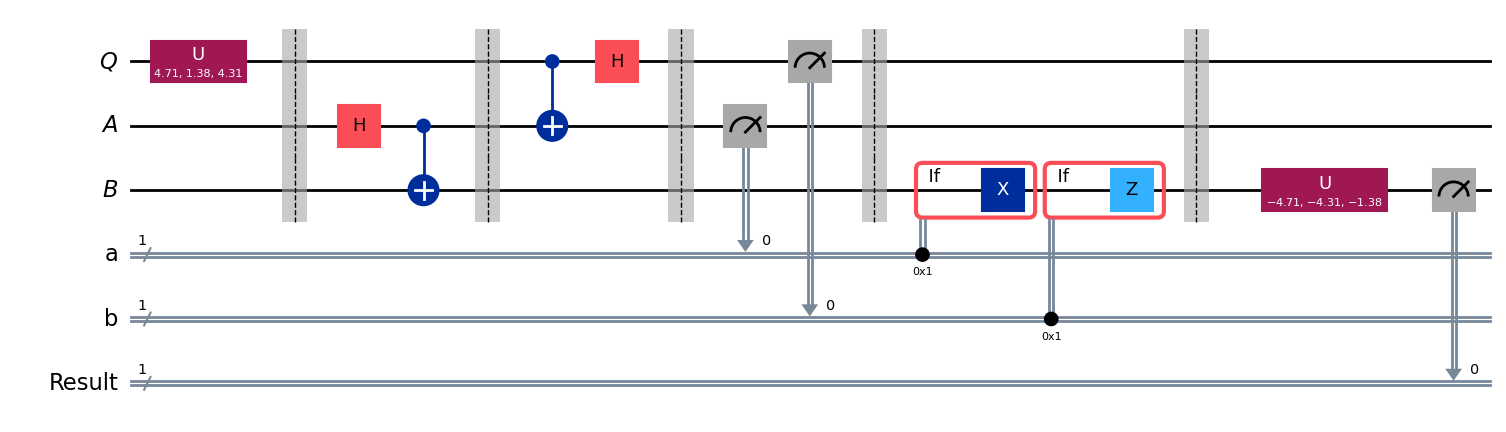

In [38]:
# Se crea un circuito nuevo que es tal cual el protocolo de teleportación visto previamente.
test = QuantumCircuit(qubit, ebitA, ebitB, a, b)

# Primero se añade la puerta unitaria aleatoria al inicio del qubit Q.

test.append(random_gate, qubit)
test.barrier()

# Se aplica el protocolo al completo mediante "compose", que básicamente pega los circuitos uno al lado del otro.

test = test.compose(protocol)
test.barrier()

# Finalmente, se aplica la inversa tras las rotaciones realizadas por el protocolo de teleportación y se mide.

test.append(random_gate.inverse(), ebitB)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebitB, result)

display(test.draw(output="mpl"))

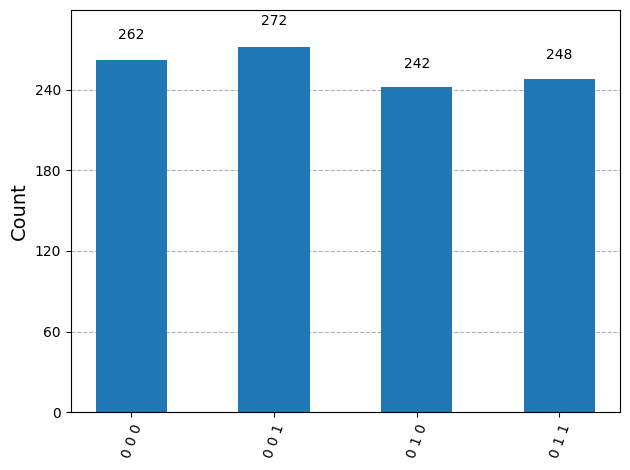

In [39]:
# Simulación mediante Aer para comprobar el éxito. El qubit más a la izquierda/abajo siempre debe ser 0 lo cual garantiza
# el éxito. Los otros dos pueden ser decentemente homogéneos.

result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

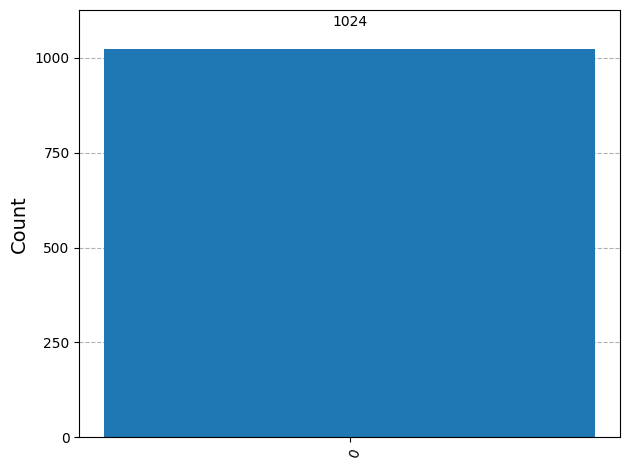

In [40]:
# Gráfica centrada específicamente en el dato que es de interés.

filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

## Codificación superdensa

Siguiendo la teoría y el circuito definido, se puede obtener el siguiente circuito para transmitir dos bits clásicos a cambio de un ebit. Un proceso muy costoso a cambio de un beneficio relativamente pequeño (obtener dos bits clásicos a cambio de un ebit). Pero aún así es interesante dada la cuestión respecto al teorema de *Holevo*, ya que este afirma que no es posible enviar más de un bit clásico usando un qubit entrelazado. La codificación superdensa duplica la cantidad de información clásica que es posible enviar.

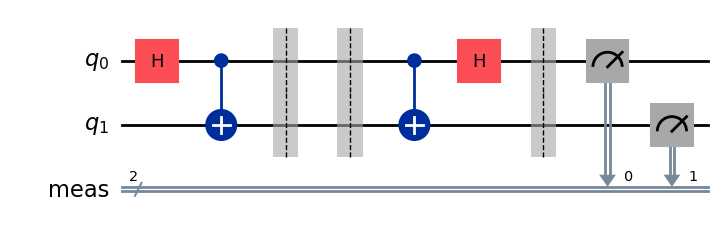

In [41]:
# Información a enviar, por ahora fija pero se puede aleatorizar.
c = "1"
d = "0"

protocol = QuantumCircuit(2)

# Dos qubits serán empleados para la tarea, q0 y q1. Se entrelazan mediante un par de Bell.
protocol.h(0)
protocol.cx(0,1)
protocol.barrier()

# Una vez realizada esta acción, igual que antes, se aplican rotaciones condicionales en q0 según los bits seleccionados c,d.
# En esta ocasión, dada la naturaleza no probabilística de c y d, se realizan ifs normales.
if d == 1:
    protocol.z(0)
if c == 1:
    protocol.x(0)
protocol.barrier()

# Finalmente, se realizan la CNOT y H sobre q0 del protocolo, y se miden.
protocol.cx(0,1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))

La mayor novedad es el método **measure_all**, el cual permite realizar las mediciones en orden del circuito tal cual está diseñado y lo reduce a un solo registro clásico, dando dos bits.

Measured 00 with frequency 1024


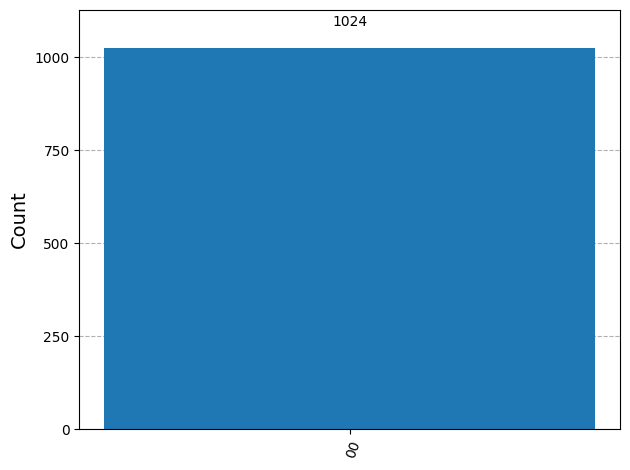

In [43]:
# Simulación con Aer
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

Ahora haciendo uso de un qubit para escoger de forma aleatoria c y d y lanzar el protocolo.

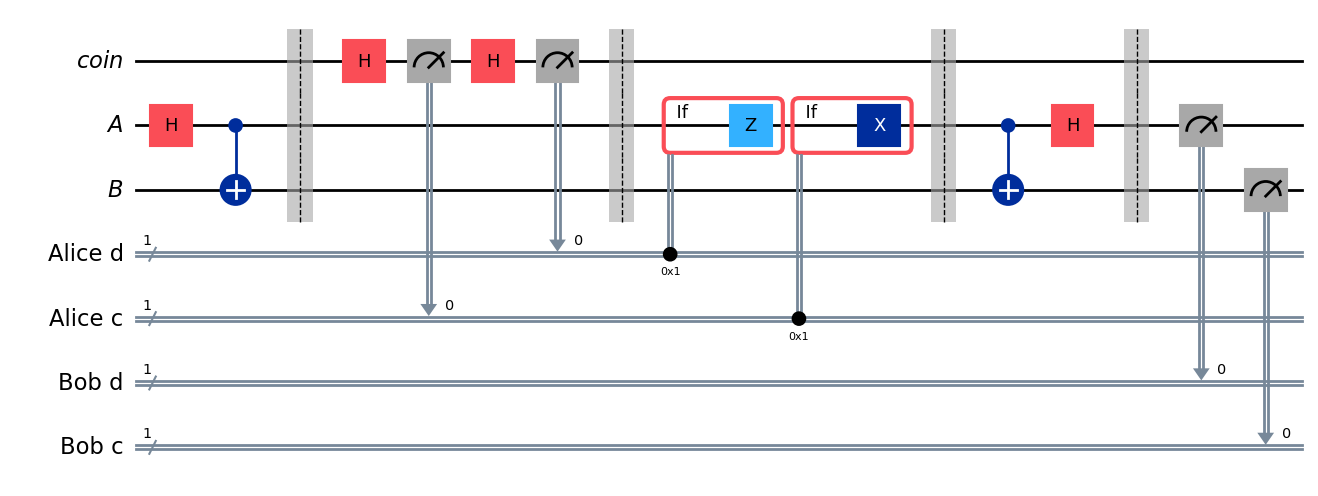

In [44]:
rbg = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# Inicialización del ebit como en el protocolo como un estado de Bell
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# Aplicar una Hadamard para superposición de statevectors 0 y 1, simulando una moneda que se lanza 2 veces con 2 medidas.
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Se lanza el protocolo de la misma forma, y las acciones (que al depender de un qubit esta vez si usan if_test)
# se separan según si salió 1 o no previamente en la moneda.
with test.if_test((Alice_d, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label="X"):
    test.x(ebit0)
test.barrier()

# Bob deshace las operaciones iniciales para tener el resultado inicial y almacena los bits clásicos con las medidas
# como se observó en el ejemplo no aleatorio.
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output="mpl"))

Al lanzar la simulación, los bits clásicos de Alice y los de Bob siempre coinciden.

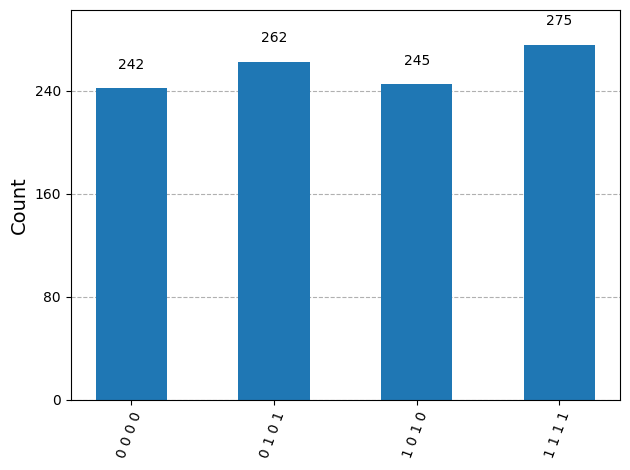

In [45]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))